# Implementation of decision tree algos (classification and regression)

In [2]:
from utils.imports import *

## Data prep

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [4]:
iris_raw=load_iris()
# print(iris_raw.feature_names)

X= pd.DataFrame(iris_raw.data,columns=iris_raw.feature_names)
Y= pd.DataFrame(iris_raw.target)

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.33,random_state=39)

## Actual DT impl

In [5]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [6]:
classifier= DecisionTreeClassifier()
classifier.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.9, 'x[2] <= 2.6\ngini = 0.666\nsamples = 100\nvalue = [35, 32, 33]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[3] <= 1.75\ngini = 0.5\nsamples = 65\nvalue = [0, 32, 33]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[2] <= 4.95\ngini = 0.114\nsamples = 33\nvalue = [0, 31, 2]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.3, 0.3, 'x[3] <= 1.6\ngini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.8, 0.5, 'x[2] <= 4.85\ngini = 0.061\nsamples = 32\nvalue = [0, 1, 31]'),
 Text(0.7, 0.3, 'x[0] <= 5.95\ngini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 29\nvalue = [0, 0, 29]')]

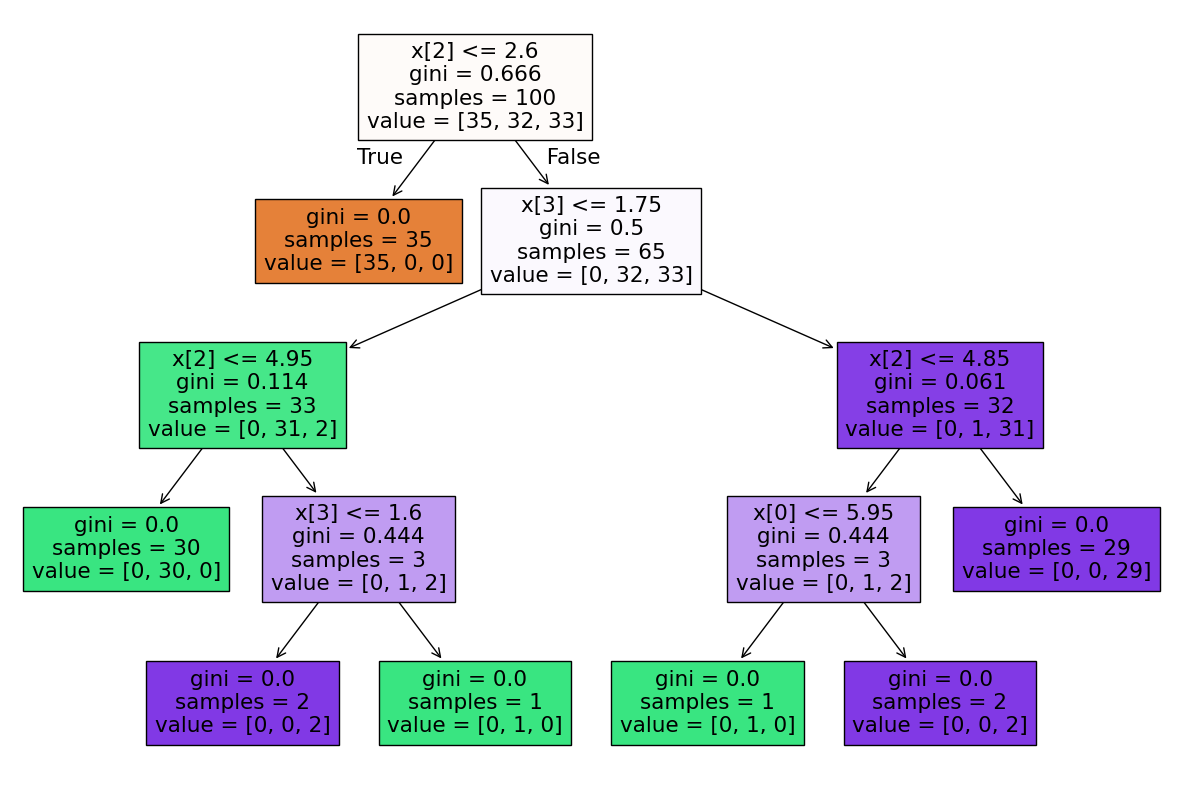

In [7]:
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)

In [8]:
from sklearn.metrics import mean_squared_error

In [9]:
y_pred=classifier.predict(x_test)
print("Accuracy: ",1-mean_squared_error(y_test,y_pred))

Accuracy:  0.96


## With hyperparam tuning

In [10]:
from sklearn.model_selection import GridSearchCV

In [27]:
classifier= DecisionTreeClassifier(random_state=44)
params={'min_samples_split':[1,2,3,5,7],'criterion':['gini','entropy','log_loss']}
dt_grid_classifier=GridSearchCV(classifier,params,cv=10)
dt_grid_classifier.fit(x_train,y_train)

,estimator,DecisionTreeC...ndom_state=44)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'min_samples_split': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [28]:
y_pred=dt_grid_classifier.predict(x_test)
print("Accuracy: ",1-mean_squared_error(y_test,y_pred))
print("Best Params",dt_grid_classifier.best_params_)

Accuracy:  0.96
Best Params {'criterion': 'gini', 'min_samples_split': 2}
